## Revision : LSTM

##### basic overlook at the LSTM based concepts, targeting single feature 
##### and trying to get back to the concepts

In [1]:
### Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas_datareader as pdr
import os
from dotenv import load_dotenv

In [2]:
### api key, keeping it hidden
load_dotenv('../keys.txt')
key = os.getenv('key')

In [29]:
### loading the data for Microsoft
df_MSFT = pdr.get_data_tiingo('MSFT', api_key = key)
df_MSFT.head()

close    high     low    open    volume  \
symbol date                                                                  
MSFT   2021-04-29 00:00:00+00:00  252.51  256.10  249.00  255.46  40589023   
       2021-04-30 00:00:00+00:00  252.18  253.08  249.60  249.74  30945098   
       2021-05-03 00:00:00+00:00  251.86  254.35  251.12  253.40  19626568   
       2021-05-04 00:00:00+00:00  247.79  251.21  245.76  250.97  32756052   
       2021-05-05 00:00:00+00:00  246.47  249.50  245.82  249.06  21901325   

                                    adjClose     adjHigh      adjLow  \
symbol date                                                            
MSFT   2021-04-29 00:00:00+00:00  242.278833  245.723374  238.911051   
       2021-04-30 00:00:00+00:00  241.962204  242.825738  239.486740   
       2021-05-03 00:00:00+00:00  241.655169  244.044280  240.945153   
       2021-05-04 00:00:00+00:00  237.750077  241.031506  235.802328   
       2021-05-05 00:00:00+00:00  236.483561  239.390792  235.859897   

                                     adjOpen  adjVolume  divCash  splitFactor  
symbol date                                                                    
MSFT   2021-04-29 00:00:00+00:00  245.109305   40589023      0.0          1.0  
       2021-04-30 00:00:00+00:00  239.621067   30945098      0.0          1.0  
       2021-05-03 00:00:00+00:00  243.132772   19626568      0.0          1.0  
       2021-05-04 00:00:00+00:00  240.801230   32756052      0.0          1.0  
       2021-05-05 00:00:00+00:00  238.968619   21901325      0.0          1.0

In [30]:
### tageting the 4 features at the time : close, high, low and open
features_to_target = ['close', 'high', 'low', 'open']
df_stock_MSFT = df_MSFT[features_to_target].values
df_stock_MSFT

array([[252.51  , 256.1   , 249.    , 255.46  ],
       [252.18  , 253.08  , 249.6   , 249.74  ],
       [251.86  , 254.35  , 251.12  , 253.4   ],
       ...,
       [424.62  , 424.95  , 415.8   , 416.97  ],
       [424.82  , 427.11  , 417.0701, 422.375 ],
       [429.25  , 429.92  , 421.9   , 424.57  ]])

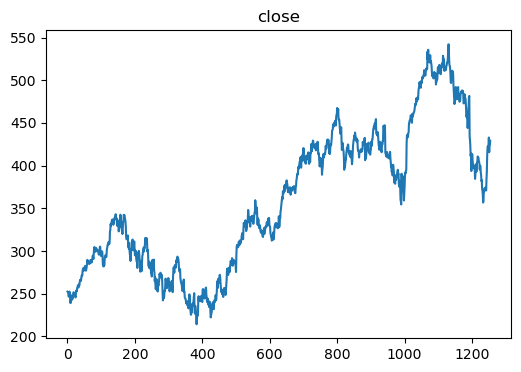

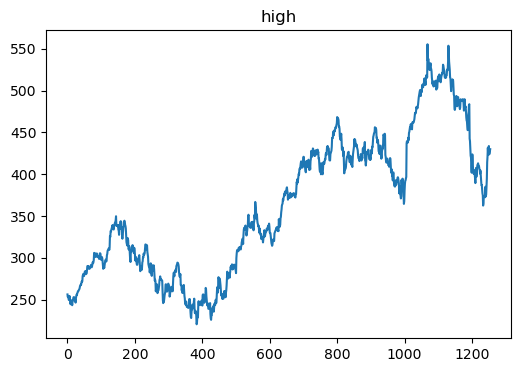

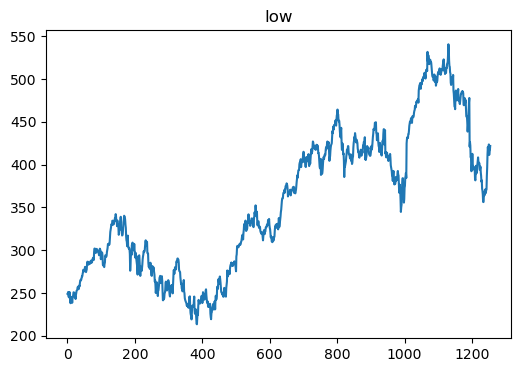

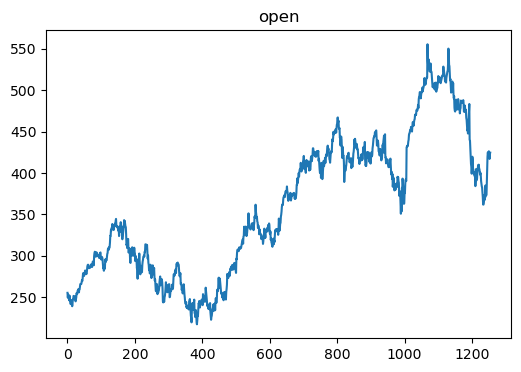

In [31]:
### plotting the graphs
for i in range (0, 4) : 
    plt.figure(figsize = (6, 4))
    plt.title(features_to_target[i])
    plt.plot(df_stock_MSFT[:, i])

In [32]:
### applying the minmax scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
df_stock_MSFT = scaler.fit_transform(df_stock_MSFT)
df_stock_MSFT

array([[0.11671039, 0.10652459, 0.10866105, 0.11226771],
       [0.11570374, 0.09751074, 0.11049401, 0.09532835],
       [0.11472759, 0.10130134, 0.11513752, 0.10616717],
       ...,
       [0.64172412, 0.61049427, 0.61822453, 0.59056785],
       [0.64233421, 0.61694126, 0.62210461, 0.60657437],
       [0.65584772, 0.62532832, 0.63685965, 0.6130747 ]])

In [33]:
### checking the shape
df_stock_MSFT.shape

(1255, 4)

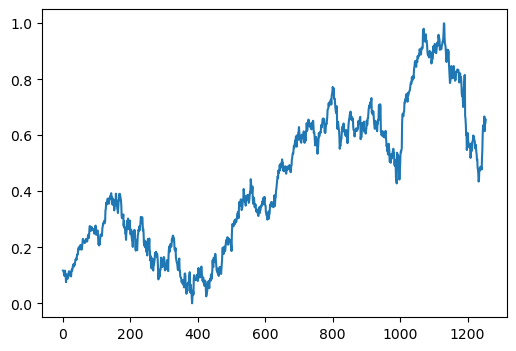

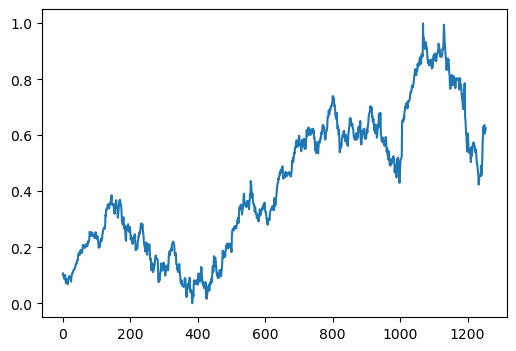

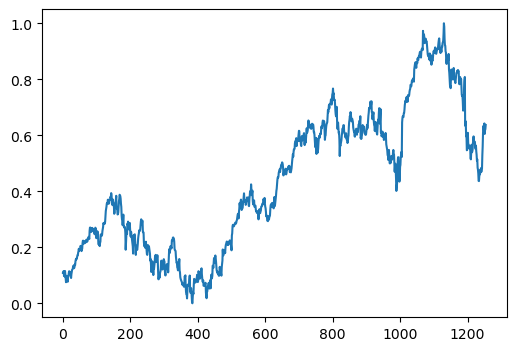

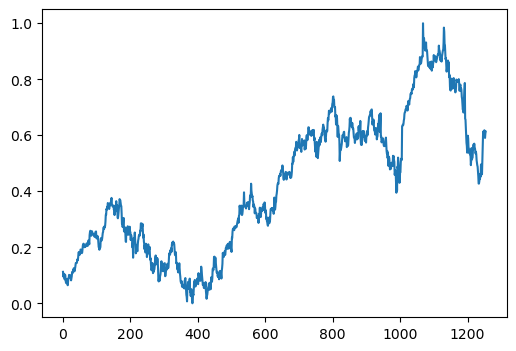

In [34]:
### plotting the graphs again for the comparison
for i in range(0, 4) : 
    plt.figure(figsize = (6, 4))
    plt.plot(df_stock_MSFT[:, i])

In [35]:
### making the sequnces, target 90 days sequence
days = 90
X, y = [], []
for i in range(len(df_stock_MSFT) - days) : 

    X.append(df_stock_MSFT[i : i + days, :])
    y.append(df_stock_MSFT[i + days , :])

X = np.array(X)
y = np.array(y)

In [36]:
### checking the sequnces (X and y)
X

array([[[0.11671039, 0.10652459, 0.10866105, 0.11226771],
        [0.11570374, 0.09751074, 0.11049401, 0.09532835],
        [0.11472759, 0.10130134, 0.11513752, 0.10616717],
        ...,
        [0.26715881, 0.25304441, 0.26901469, 0.25265418],
        [0.2650845 , 0.24758298, 0.26501272, 0.25068483],
        [0.26505399, 0.24531399, 0.26525712, 0.2471015 ]],

       [[0.11570374, 0.09751074, 0.11049401, 0.09532835],
        [0.11472759, 0.10130134, 0.11513752, 0.10616717],
        [0.10231224, 0.09192932, 0.09876306, 0.0989709 ],
        ...,
        [0.2650845 , 0.24758298, 0.26501272, 0.25068483],
        [0.26505399, 0.24531399, 0.26525712, 0.2471015 ],
        [0.26212556, 0.24080707, 0.25896395, 0.24714592]],

       [[0.11472759, 0.10130134, 0.11513752, 0.10616717],
        [0.10231224, 0.09192932, 0.09876306, 0.0989709 ],
        [0.09828564, 0.08682545, 0.09894635, 0.09331458],
        ...,
        [0.26505399, 0.24531399, 0.26525712, 0.2471015 ],
        [0.26212556, 0.240807

In [37]:
### checking the y
y

array([[0.26212556, 0.24080707, 0.25896395, 0.24714592],
       [0.26221707, 0.2393744 , 0.25671888, 0.24351818],
       [0.25318772, 0.24394102, 0.25529802, 0.24659806],
       ...,
       [0.64172412, 0.61049427, 0.61822453, 0.59056785],
       [0.64233421, 0.61694126, 0.62210461, 0.60657437],
       [0.65584772, 0.62532832, 0.63685965, 0.6130747 ]])

In [38]:
### at 91th index of X should match the 1st index of y
print(f"{X.shape} :: {y.shape}")

(1165, 90, 4) :: (1165, 4)


In [39]:
### veryfying the sequences
X[2][89]

array([0.26221707, 0.2393744 , 0.25671888, 0.24351818])

In [40]:
### spliting the train-test data (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [41]:
### checking the shape
print(f"{X_train.shape} : {y_train.shape} :: {X_test.shape} : {y_test.shape}")

(932, 90, 4) : (932, 4) :: (233, 90, 4) : (233, 4)


In [18]:
### importing the tesnorflow libraries to build the model
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout

In [42]:
### building the sequential model
model = Sequential([
    LSTM(50, return_sequences = True, input_shape = (days, 4)),
    Dropout(0.33),
    Bidirectional(LSTM(100)),
    Dropout(0.33),
    Dense(4, activation = 'linear')
])
model.compile(optimizer = 'rmsprop', loss = 'mean_squared_error', metrics = ['mse'])

c:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
### checking the model summary now
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 90, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 90, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 200)            │       120,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,604 (517.98 KB)

 Trainable params: 132,604 (517.98 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
### training the model
model.fit(X_train, y_train, epochs = 40, batch_size = 32, verbose = 1)

Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0699 - mse: 0.0699
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0108 - mse: 0.0108
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0081 - mse: 0.0081
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0080 - mse: 0.0080
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0075 - mse: 0.0075
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0059 - mse: 0.0059
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0060 - mse: 0.0060
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0058 - mse: 0.0058
Epoch 9/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0060 - mse: 0.0060
Epoch 10/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0062 - mse: 0.0062
Epoch 11/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0048 - mse: 0.0048
Epoch 12/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0050 - mse: 0.0050
Epoch 13/40
30/30 ━━━━━━━━━━━━━━━━━━━

In [45]:
### predictions by the model
y_pred = model.predict(X_test)
y_pred

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


array([[0.11533271, 0.10375729, 0.10522804, 0.09741215],
       [0.5658756 , 0.53993475, 0.5479414 , 0.52045524],
       [0.10435271, 0.09290162, 0.09325333, 0.08565291],
       [0.29790393, 0.28036088, 0.2836645 , 0.26823288],
       [0.6580888 , 0.6295433 , 0.6415035 , 0.60946023],
       [0.34781018, 0.3287865 , 0.3343563 , 0.31575993],
       [0.60991   , 0.5825147 , 0.5913359 , 0.56225896],
       [0.755175  , 0.7229755 , 0.73300135, 0.69564545],
       [0.49207515, 0.4686504 , 0.47404042, 0.44824767],
       [0.20275764, 0.1888805 , 0.18977645, 0.17736444],
       [0.64129305, 0.6133236 , 0.6247272 , 0.59312284],
       [0.4669814 , 0.4444911 , 0.45288453, 0.42949307],
       [0.3578337 , 0.33886278, 0.34498158, 0.32824883],
       [0.48871437, 0.46513593, 0.4709874 , 0.44689548],
       [0.7464886 , 0.71507806, 0.7240953 , 0.6886124 ],
       [0.17935582, 0.16564287, 0.16705339, 0.15668193],
       [0.55336446, 0.52805007, 0.5382282 , 0.51250476],
       [0.20029795, 0.18611407,

In [46]:
### y_pred.shape
y_pred.shape

(233, 4)

In [47]:
### inverse scaling the data
y_pred = scaler.inverse_transform(y_pred)
y_pred

array([[252.05836, 255.17284, 247.87625, 250.44365],
       [399.75534, 401.30972, 392.79358, 393.2947 ],
       [248.45891, 251.53575, 243.95645, 246.47285],
       [311.90887, 314.3421 , 306.28543, 308.12555],
       [429.98468, 431.33218, 423.4201 , 423.3495 ],
       [328.26913, 330.56662, 322.87888, 324.17422],
       [414.1907 , 415.57574, 406.9983 , 407.4108 ],
       [461.8115 , 462.63568, 453.3709 , 452.45206],
       [375.56207, 377.42664, 368.60294, 368.91202],
       [280.71802, 283.69254, 275.55222, 277.44153],
       [424.4787 , 425.89795, 417.9286 , 417.83273],
       [367.33585, 369.3323 , 361.67776, 362.57907],
       [331.55502, 333.9426 , 326.3569 , 328.39142],
       [374.46036, 376.2491 , 367.60355, 368.4554 ],
       [458.9639 , 459.98975, 450.45563, 450.0772 ],
       [273.04642, 275.90698, 268.1141 , 270.45758],
       [395.65393, 397.32788, 389.61407, 390.61005],
       [279.91168, 282.76566, 274.5599 , 276.69434],
       [296.53238, 299.19925, 292.13132, 294.3

In [48]:
### inverse scaling the y_test for the comparison
y_test = scaler.inverse_transform(y_test)
y_test

array([[251.11  , 251.4   , 245.61  , 246.55  ],
       [421.53  , 421.75  , 416.46  , 418.96  ],
       [240.98  , 243.86  , 237.57  , 237.8704],
       [318.955 , 320.04  , 314.    , 314.03  ],
       [450.95  , 451.42  , 446.75  , 448.25  ],
       [329.32  , 332.725 , 324.39  , 325.47  ],
       [412.37  , 413.9199, 409.74  , 412.685 ],
       [491.02  , 492.3   , 484.38  , 484.885 ],
       [420.26  , 420.82  , 412.14  , 419.86  ],
       [269.5   , 273.75  , 265.07  , 271.69  ],
       [445.7   , 446.53  , 441.27  , 446.3   ],
       [382.7   , 383.    , 378.16  , 378.35  ],
       [327.5   , 333.63  , 326.3551, 333.63  ],
       [373.11  , 377.48  , 369.35  , 374.785 ],
       [486.74  , 489.8599, 484.6475, 488.435 ],
       [261.47  , 267.11  , 261.33  , 265.39  ],
       [402.79  , 404.49  , 398.01  , 403.24  ],
       [289.63  , 290.98  , 281.4562, 285.185 ],
       [294.8   , 297.54  , 294.07  , 295.69  ],
       [449.78  , 450.58  , 446.51  , 447.38  ],
       [340.54  , 34

In [49]:
### finding out the comparsion/evaluation metrices
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
for i in range (0, 4) :
    print(f"feature : {features_to_target[i]}")
    print(mean_squared_error(y_test, y_pred))
    print(mean_absolute_error(y_test, y_pred))
    print(root_mean_squared_error(y_test, y_pred))

feature : close
301.2215970438451
13.729681994288361
17.281832429240986
feature : high
301.2215970438451
13.729681994288361
17.281832429240986
feature : low
301.2215970438451
13.729681994288361
17.281832429240986
feature : open
301.2215970438451
13.729681994288361
17.281832429240986


In [50]:
def plot_predictions(y_test, y_pred) : 
    plt.figure(figsize = (12, 4))

    #----------Plot to see the trend made by model
    plt.subplot(1, 3, 1)
    plt.plot(y_pred, label = 'Predicted')
    plt.plot(y_test, label = 'Actual')

    #----------Actual vs Predicted points
    plt.subplot(1, 3, 2)
    plt.plot(y_test, label='Actual', color='blue', marker='o')
    plt.plot(y_pred, label='Predicted', color='red', marker='x')
    plt.xlabel('Index')
    plt.ylabel('Target Value')
    plt.legend()
    plt.grid(True)

    #--------- Best fit line
    plt.subplot(1, 3, 3)
    plt.scatter(y_test, y_pred, color = 'blue', alpha = 0.5, label = 'Predicted')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color = 'red', linewidth = 2, label = 'Best fit line')
    plt.xlabel('Actual Values (y_test)')
    plt.ylabel('Predicted Values (y_pred)')
    plt.legend()
    plt.grid(True)
    plt.show()

feature : close


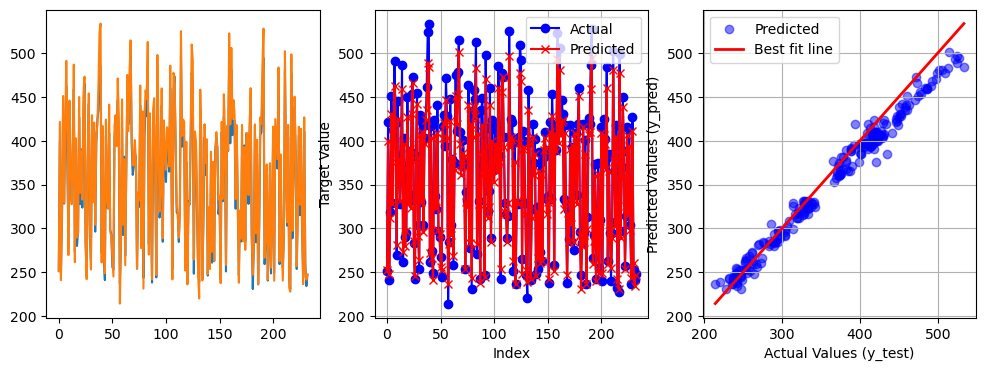

feature : high


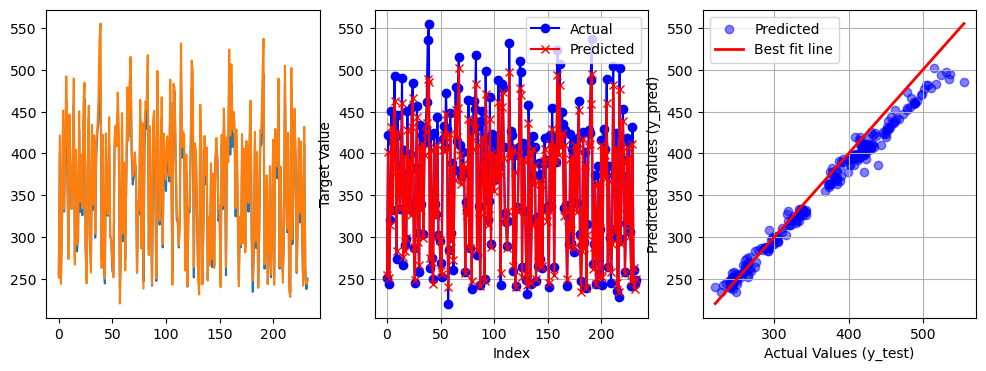

feature : low


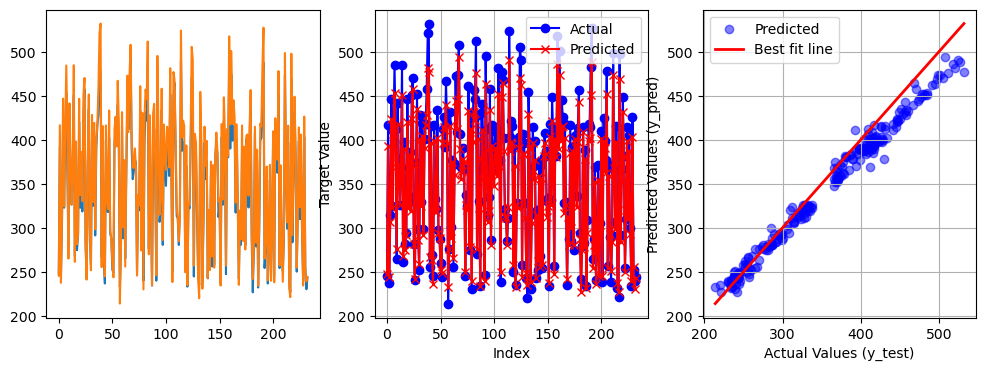

feature : open


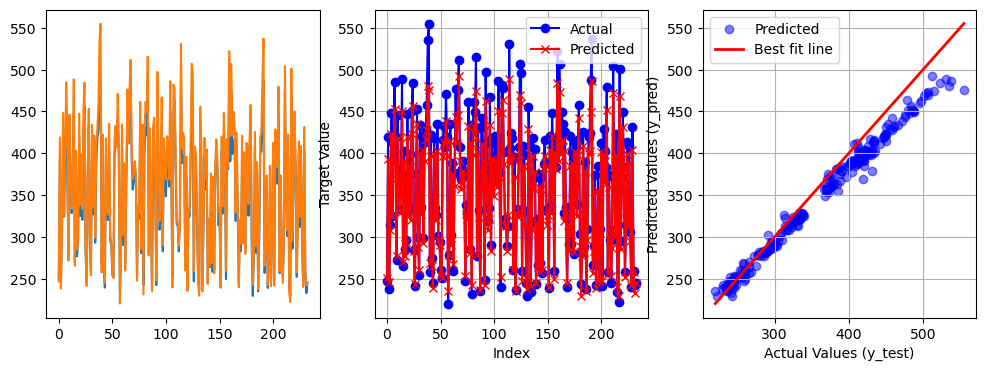

In [51]:
### plotting the comparison graphs now
for i in range(0, 4) : 
    print(f"feature : {features_to_target[i]}")
    plot_predictions(y_test[:, i], y_pred[:, i])

### Predicting the next 60 days of prices

In [79]:
future_days = 60
last_window = df_stock_MSFT[-future_days : ]
last_window

array([[0.63791105, 0.62776385, 0.63792887, 0.62985119],
       [0.60081752, 0.60183859, 0.59610679, 0.60549345],
       [0.60990788, 0.59512297, 0.59818415, 0.57288813],
       [0.54731255, 0.56079871, 0.54649461, 0.56234545],
       [0.57009944, 0.54136819, 0.54832757, 0.53783964],
       [0.60810811, 0.580468  , 0.57261432, 0.55467535],
       [0.60710146, 0.60670368, 0.60875423, 0.59841564],
       [0.57995241, 0.58515401, 0.57304201, 0.58821352],
       [0.57223476, 0.5545308 , 0.5638772 , 0.55511957],
       [0.57064853, 0.55256089, 0.5639994 , 0.55349078],
       [0.5570435 , 0.5375776 , 0.55323075, 0.53800252],
       [0.56540174, 0.54366643, 0.55871436, 0.53477456],
       [0.56192423, 0.54924785, 0.55978359, 0.54235582],
       [0.55817217, 0.53637148, 0.55517063, 0.52879248],
       [0.51924837, 0.52217646, 0.51832809, 0.52550529],
       [0.53306693, 0.50426815, 0.51408173, 0.49334419],
       [0.5684522 , 0.54041309, 0.53989595, 0.51225291],
       [0.57186871, 0.55838109,

In [55]:
### veryfying the shape
last_window.shape

(60, 4)

In [80]:
### reshaping it
last_window = np.expand_dims(last_window, axis = 0)
last_window.shape

(1, 60, 4)

In [83]:
### predicting the next 60 days price
future_preds = []
current_window = last_window.copy()

for _ in range(future_days) : 

    next_pred = model.predict(current_window, verbose = 0)
    future_preds.append(next_pred[0, : ])

    next_pred_reshaped = np.expand_dims(next_pred, axis = 0)
    current_window = np.concatenate(
        (last_window[:, 1 : , :], next_pred_reshaped), axis = 1
    )

In [84]:
future_preds

[array([0.6038817 , 0.57754475, 0.588226  , 0.55733746], dtype=float32),
 array([0.59892917, 0.5726012 , 0.58296865, 0.5526008 ], dtype=float32),
 array([0.5982975, 0.5719783, 0.5823177, 0.5519906], dtype=float32),
 array([0.59821796, 0.5718999 , 0.5822358 , 0.5519136 ], dtype=float32),
 array([0.59820783, 0.57189   , 0.58222544, 0.5519041 ], dtype=float32),
 array([0.5982066 , 0.57188874, 0.58222413, 0.55190283], dtype=float32),
 array([0.5982065 , 0.57188857, 0.582224  , 0.55190265], dtype=float32),
 array([0.59820646, 0.57188857, 0.582224  , 0.55190265], dtype=float32),
 array([0.59820646, 0.57188857, 0.582224  , 0.55190265], dtype=float32),
 array([0.59820646, 0.57188857, 0.582224  , 0.55190265], dtype=float32),
 array([0.59820646, 0.57188857, 0.582224  , 0.55190265], dtype=float32),
 array([0.59820646, 0.57188857, 0.582224  , 0.55190265], dtype=float32),
 array([0.59820646, 0.57188857, 0.582224  , 0.55190265], dtype=float32),
 array([0.59820646, 0.57188857, 0.582224  , 0.55190265]

In [85]:
future_preds = scaler.inverse_transform(future_preds)
future_preds

array([[412.21450438, 413.91059263, 405.98031727, 405.74892779],
       [410.59095946, 412.25430576, 404.25937566, 404.14947547],
       [410.38387883, 412.04559992, 404.04629685, 403.94343539],
       [410.35781301, 412.01933945, 404.01948884, 403.91743131],
       [410.35449128, 412.01602444, 404.01609394, 403.91421099],
       [410.35408095, 412.01560507, 404.0156647 , 403.91378832],
       [410.35406141, 412.01554516, 404.01562567, 403.91372794],
       [410.35404187, 412.01554516, 404.01562567, 403.91372794],
       [410.35404187, 412.01554516, 404.01562567, 403.91372794],
       [410.35404187, 412.01554516, 404.01562567, 403.91372794],
       [410.35404187, 412.01554516, 404.01562567, 403.91372794],
       [410.35404187, 412.01554516, 404.01562567, 403.91372794],
       [410.35404187, 412.01554516, 404.01562567, 403.91372794],
       [410.35404187, 412.01554516, 404.01562567, 403.91372794],
       [410.35404187, 412.01554516, 404.01562567, 403.91372794],
       [410.35404187, 412

In [86]:
future_preds.shape

(60, 4)